
## Lab1.1: Análisis exploratorio de datos con PANDAS y NUMPY

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

data = sns.load_dataset("penguins").dropna().values
df = pd.DataFrame(data, columns=["especie", "isla", "longitud_pico (mm)", "profundidad_pico (mm)", "longitud_aleta (mm)", "masa_corporal (g)", "genero"])

df[:5]

,especie,isla,longitud_pico (mm),profundidad_pico (mm),longitud_aleta (mm),masa_corporal (g),genero
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Esto cargará un dataframe (df), usando la librería seaborn, con algunas características morfológicas y geográficas de diferentes especies de pingüinos. Las columnas contienen los siguientes datos:

```
[especie, isla, longitud del pico, profundidad del pico, longitud de la aleta, masa corporal, genero]
```

https://github.com/allisonhorst/palmerpenguins/blob/main/man/figures/lter_penguins.png

## Laboratorio_1.1

1.   ¿Cuáles son las profundidades del pico máxima y mínima de los pinguinos de la isla Torgersen?

2.    ¿De qué isla, especie y género es el pingüino con la mayor masa corporal?
       **Ayuda:** utilice la función `argmax()`

3.   ¿Cuál es la masa corporal media de los pinguinos macho que no son de la especie Gentoo?

4.   Grafique la distribución de la longitud del pico. Añada el valor medio y la desviación estándar en el título de la figura. **Ayuda:** utilice la funcion `hist()`

5.   ¿Cuáles son las islas y especies presentes en el conjunto de datos? ¿Con qué frecuencia aparecen? Grafique la distribución de la masa corporal para los pingüinos.




  



### Solución punto 1

In [2]:
# Seleccionamos los pingüinos (supongo que las especies) que viven en la isla Torgersen. 
# Esta variable puede pensarse como otro df donde eliminamos (seleccionamos una de tantas) la columna isla.
torgersen = df[df.isla=='Torgersen']

# Ahora buscamos el de mayor y menor pico (decir buscamos es mucha vaina, algoritmos para eso hay muchos, solo lo uso).
# El espacio en el nombre de la columna obliga (creo) a usar este formato para seleccionar la columna del df.

print(f"La profundidad del pico máxima de los pingüinos de la isla Torgersen es: {np.max(torgersen['longitud_pico (mm)'])} mm.")
print(f"La profundidad del pico mínima de los pingüinos de la isla Torgersen es: {np.min(torgersen['longitud_pico (mm)'])} mm.")


La profundidad del pico máxima de los pingüinos de la isla Torgersen es: 46.0 mm.
La profundidad del pico mínima de los pingüinos de la isla Torgersen es: 33.5 mm.


picos malos ??? lo picos son 20 mm ?

### Solución punto 2

In [3]:
# Ahora debemos seleccionar la columna de masa corporal
masa_corporal = df['masa_corporal (g)']
# Encontrar el índice del máximo. Es muy simple una vez se conoce el máximo, al menos en algunos algoritmos (creo).
índice = np.argmax(masa_corporal)
print(f'La isla, especie y género del pingüino de mayor masa corporal son {df.isla[índice]}, {df.especie[índice]}, {df.genero[índice]}, respectivamente.')

La isla, especie y género del pingüino de mayor masa corporal son Biscoe, Gentoo, Male, respectivamente.


bien

### Solución punto 3

In [4]:
# Primero necesitamos seleccionar los pingüinos que en la columna especie tienen un valor distinto a Gentoo.
# Es sencillo, ponemos una máscara booleana:
no_gentoo = df[df.especie != "Gentoo"]
# de esos berracos, escogemos los machos
no_gentoo_macho = no_gentoo[no_gentoo.genero == "Male"]
# y de esos individuos le sacamos la media con np.mean
print(f'la media de los machos de los pingüinos que no son de la especie Gentoo es: {np.mean(no_gentoo_macho['masa_corporal (g)']):.2f}')

la media de los machos de los pingüinos que no son de la especie Gentoo es: 4010.28


bien

### Solución punto 4

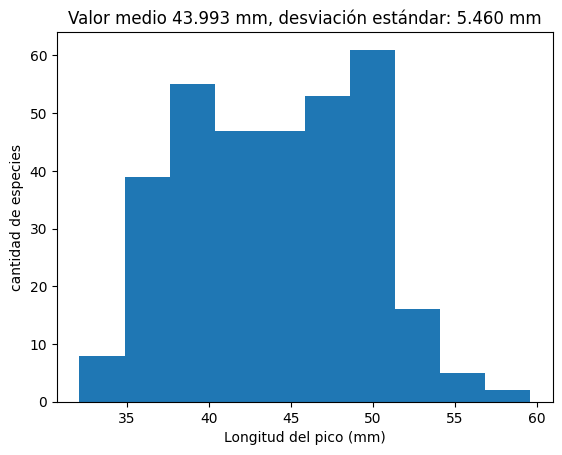

In [5]:
# Si se nos pide sin más la distribución tampoco habrá que matarse la cabeza inventando, caeré en el "laconismo" de la instrucción.
# El problema con las instrucciones lacónicas es que uno termina adivinando qué es lo que evalúan, ¿el histograma debe hacerse con numpy o con matplotlib?
# Lo pregunto porque ambas librerías tienen sus funciones para "construir" un histograma.
# He de suponer que, si nos piden "grafique" y la función "hist" se pretende usar matplotlib.
# Pero entonces, ¿por qué no se importó desde el inicio como numpy? ¿es una trampa? ¿le estoy dando muchas vueltas al asunto y se perdió lo lacónico de la solución?
# Ante la duda... matplotlib.
import matplotlib.pyplot as plt

# Basta con poner los datos de los que queremos la distribución como argumento de la función
plt.hist(df['longitud_pico (mm)'])
plt.xlabel("Longitud del pico (mm)")
plt.ylabel("cantidad de especies")
plt.title(f'Valor medio {np.mean(df['longitud_pico (mm)']):.3f} mm, desviación estándar: {np.std(df['longitud_pico (mm)']):.3f} mm')
plt.show()

# ¿Quiere algo más? ¿la gráfica debe estar decorada, comentada, citada en algún lado, le aplicamos Chi^2? ¿hacemos algo más?

bien ... cifras sign.

### Solución punto 5.

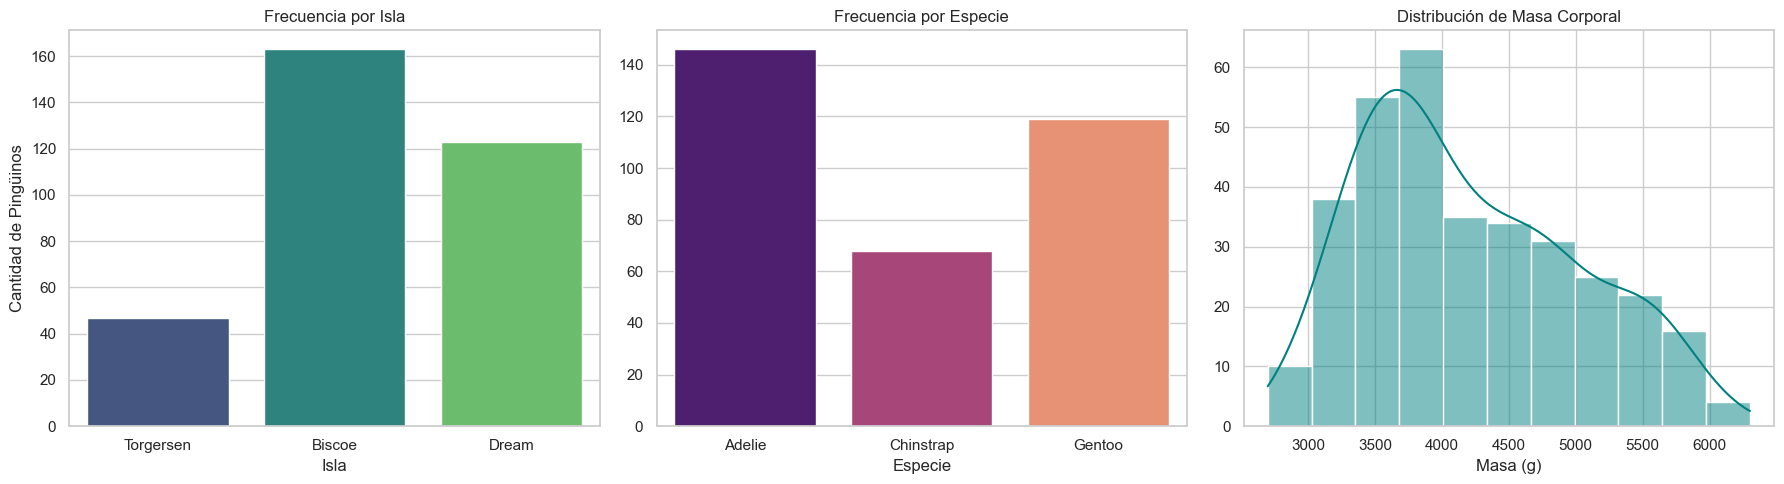

In [ ]:


# Configuramos el estilo y el tamaño de la figura (3 columnas, 1 fila)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Frecuencia por Isla
sns.countplot(data=df, x='isla', ax=axes[0], palette='viridis', hue='isla', legend=False)
axes[0].set_title('Frecuencia por Isla')
axes[0].set_xlabel('Isla')
axes[0].set_ylabel('Cantidad de Pingüinos')

# 2. Frecuencia por Especie
sns.countplot(data=df, x='especie', ax=axes[1], palette='magma', hue='especie', legend=False)
axes[1].set_title('Frecuencia por Especie')
axes[1].set_xlabel('Especie')
axes[1].set_ylabel('') # Quitamos para no saturar

# 3. Distribución de Masa Corporal
sns.histplot(data=df, x='masa_corporal (g)', kde=True, ax=axes[2], color='teal')
axes[2].set_title('Distribución de Masa Corporal')
axes[2].set_xlabel('Masa (g)')
axes[2].set_ylabel('')

# Ajuste fino para que no se encimen los textos
plt.tight_layout()
plt.show()

falta frecuencias...nota 4.5.... corregirlo...